# Telecom Customer Churn Analysis
## Notebook 02 – Exploratory Data Analysis (EDA)

### Objective

This notebook explores customer behaviour, identifies churn patterns, and uncovers the key business factors influencing customer churn.

### Dataset

- Source: IBM Telecom Customer Churn Dataset
- Records: 7,043 customers
- Features: 23 columns (after feature engineering)

### Analysis Goals

- Understand customer demographics
- Analyse churn behaviour
- Explore revenue-related variables
- Identify high-risk customer segments
- Generate business insights for retention strategies

In [41]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Clean Dataset

In [42]:
# ==========================================================
# Load Clean Dataset
# ==========================================================

df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

print("Clean dataset loaded successfully.")

Clean dataset loaded successfully.


In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,Tenure_Band
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months


In [44]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 23


## Dataset Overview

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [46]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Binary
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [47]:
df.describe(include="object")

C:\Users\ritik\AppData\Local\Temp\ipykernel_13920\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,Tenure_Band
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,4
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,49-72 Months
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174,2239


# Overall Customer Churn

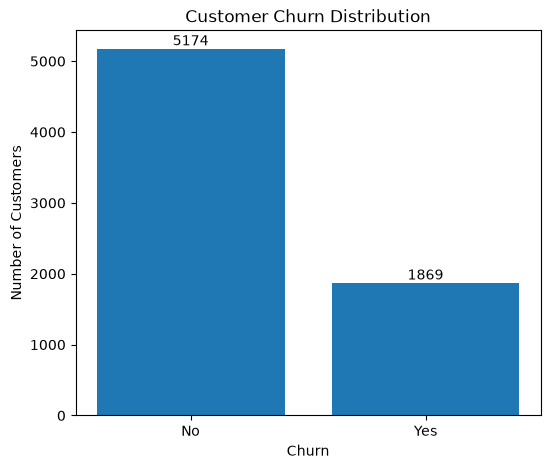

In [48]:
# ==========================================================
# Overall Customer Churn
# ==========================================================

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

### Business Insight

- Approximately 26.5% of customers have churned.
- Nearly three out of every four customers remain active.
- Although most customers are retained, the churn rate is high enough to represent a significant business problem.
- This supports further investigation into the characteristics of customers who are most likely to leave.

# Churn Percentage

In [49]:
# ==========================================================
# Churn Percentage
# ==========================================================

churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


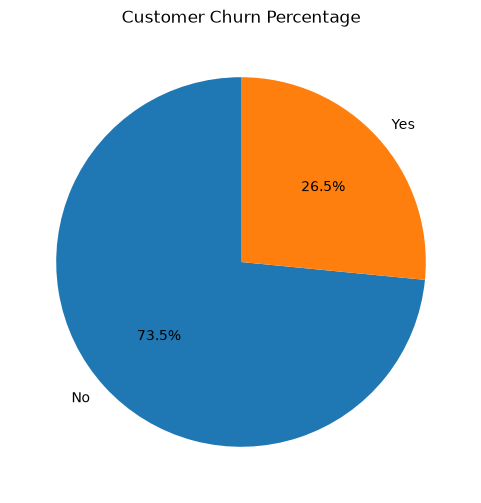

In [50]:
plt.figure(figsize=(6,6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

### Business Insight

- The company retains approximately 73% of its customers.
- However, more than one in four customers discontinue the service.
- A churn rate above 25% represents a substantial loss of recurring revenue and highlights the need for targeted retention strategies.

# Customer Gender Distribution

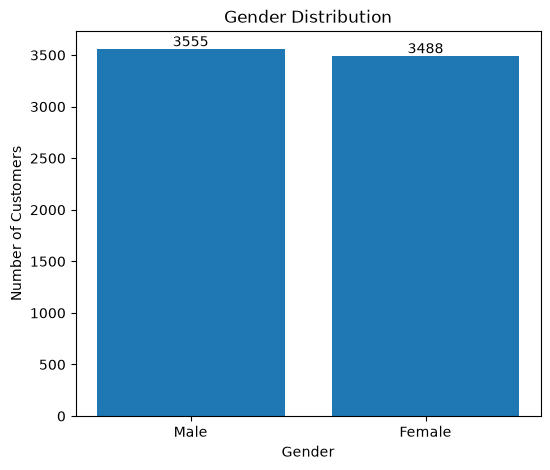

In [51]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

for i, value in enumerate(gender_counts.values):
    plt.text(i, value + 30, str(value), ha="center")

plt.show()

### Business Insight

- The customer base is almost evenly split between male and female customers.
- This indicates that gender alone is unlikely to explain churn behaviour.
- Further analysis should compare churn rates across genders rather than relying on customer counts alone.

# Contract Type vs Customer Churn

In [52]:
# ==========================================================
# Contract Type vs Churn
# ==========================================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


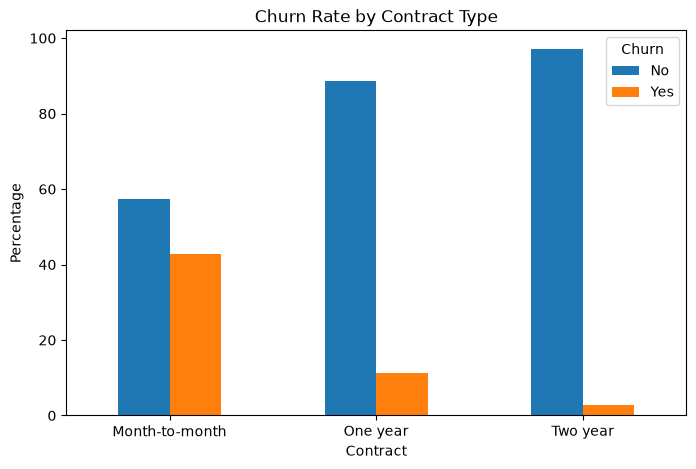

In [53]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")

plt.xlabel("Contract")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

### Business Insight

- Month-to-month customers have the highest churn rate by a large margin.
- Customers on one-year and two-year contracts are significantly more loyal.
- Encouraging customers to migrate from month-to-month plans to longer contracts could substantially reduce churn.

# Internet Service vs Customer Churn

In [54]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


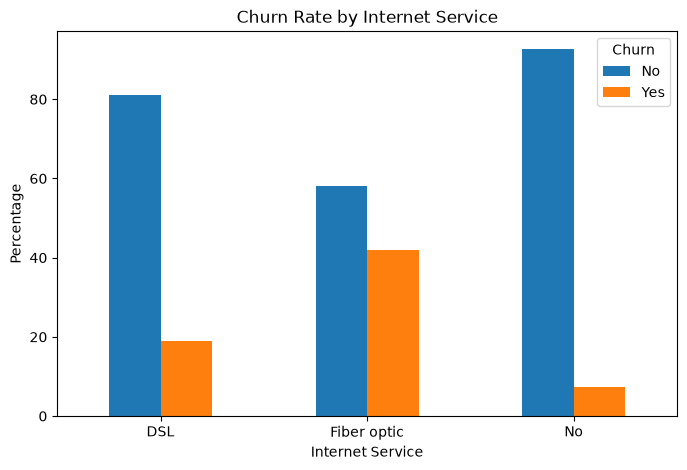

In [55]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service")

plt.xlabel("Internet Service")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

# Payment Method vs Customer Churn

In [56]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


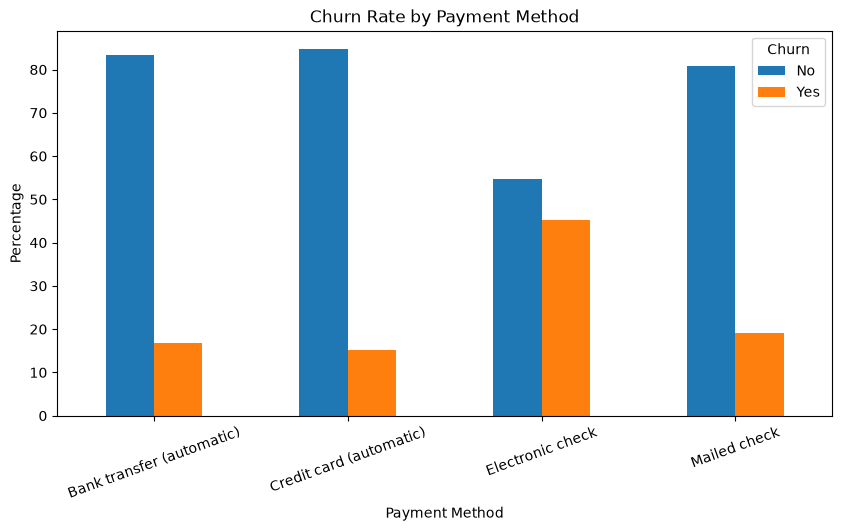

In [57]:
payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Percentage")

plt.xticks(rotation=20)

plt.show()

### Business Insight

- Customers paying through Electronic Check have the highest churn rate.
- Automatic payment methods are associated with stronger customer retention.
- Encouraging customers to switch to automated payment methods may improve retention.

# Customer Tenure Distribution

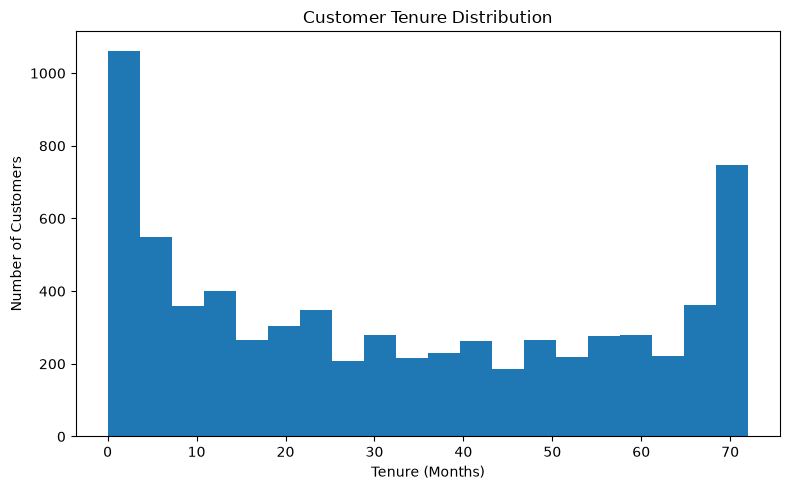

In [58]:
plt.figure(figsize=(8,5))

plt.hist(
    df["tenure"],
    bins=20
)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure (Months)")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../visualizations/56_tenure_distribution.png",
    dpi=300
)

plt.show()

### Business Insight

- A large proportion of customers have relatively short tenure.
- Early customer lifecycle is the highest-risk period.
- Improving onboarding and customer engagement during the first year could significantly reduce churn.

# Monthly Charges Distribution

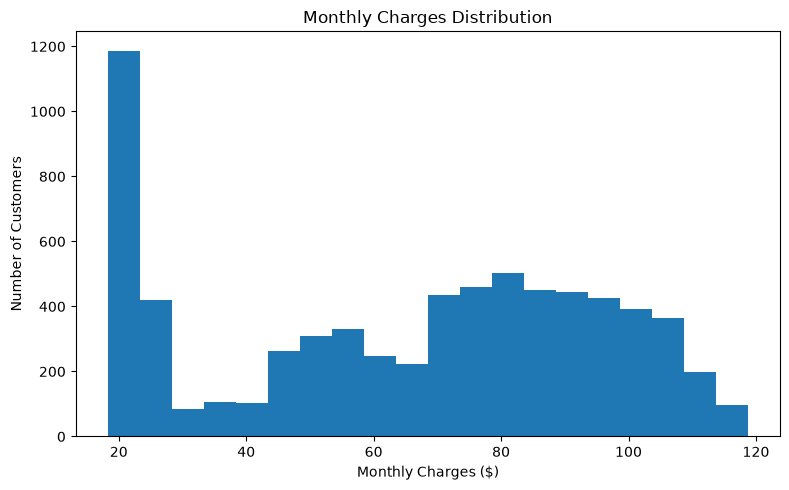

In [59]:
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyCharges"],
    bins=20
)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges ($)")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../visualizations/57_monthly_charges_distribution.png",
    dpi=300
)

plt.show()

### Business Insight

- Customers are distributed across a wide range of monthly charges.
- Higher monthly charges warrant further investigation to determine whether they contribute to increased churn.

# Monthly Charges vs Customer Churn

<Figure size 800x500 with 0 Axes>

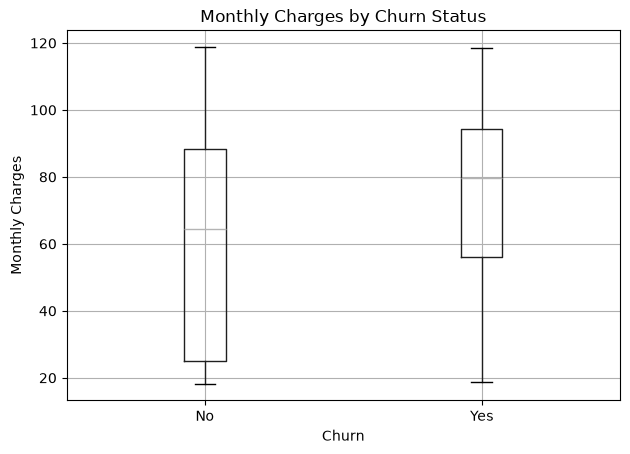

In [60]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")

plt.suptitle("")

plt.xlabel("Churn")

plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "../visualizations/58_monthly_charges_vs_churn.png",
    dpi=300
)

plt.show()

### Business Insight

- Customers who churn tend to have higher monthly charges.
- Premium-priced customers appear more likely to leave.
- Pricing strategy and perceived value should be reviewed for high-paying customers.

# Correlation Heatmap

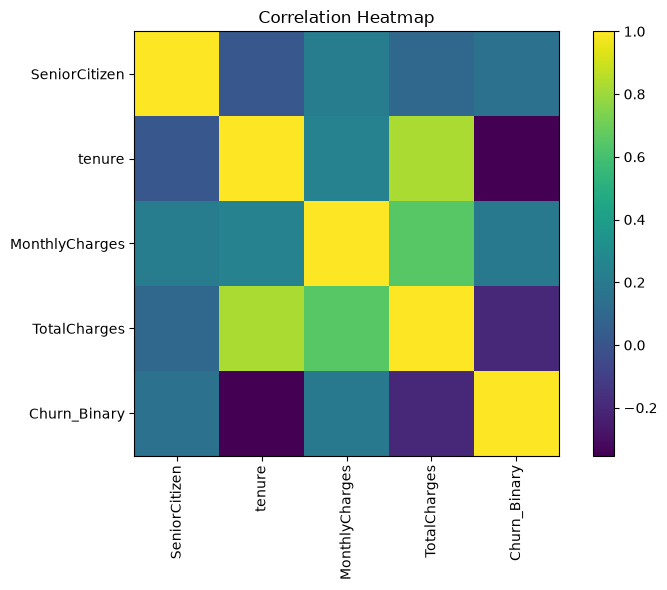

In [61]:
correlation = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../visualizations/59_correlation_heatmap.png",
    dpi=300
)

plt.show()

### Business Insight

- Monthly Charges exhibit a positive relationship with churn.
- Total Charges strongly correlate with customer tenure.
- Churn is influenced by multiple factors rather than a single variable, reinforcing the need for multivariate analysis.

# Key Findings

## Major Insights

- Overall churn rate is approximately **26.5%**.
- Month-to-month contracts experience the highest churn.
- Fiber optic customers exhibit the highest churn.
- Electronic Check users are at the greatest risk.
- Customers with shorter tenure churn significantly more often.
- Customers paying higher monthly charges are more likely to churn.

## Business Recommendations

- Encourage migration to long-term contracts.
- Improve onboarding during the first year.
- Investigate Fiber optic service experience.
- Promote automatic payment methods.
- Develop targeted retention campaigns for high-value customers.